# Aprendizado Contrastivo

Neste notebook exploraremos o **Aprendizado Contrastivo**, uma abordagem de aprendizado auto-supervisionado. Em vez de prever um rótulo, aprendemos um espaço de representações no qual exemplos parecidos ficam próximos e exemplos diferentes ficam distantes.

O modelo é treinado com **pares positivos**, duas visões do mesmo conceito que devem se atrair, e **pares negativos**, visões de conceitos distintos que devem se repelir. Não usamos rótulos humanos: os pares positivos são gerados aplicando duas transformações diferentes sobre a mesma imagem.

Usaremos o dataset **Omniglot**, com caracteres manuscritos de vários alfabetos, e a função de perda **InfoNCE**, base de métodos como SimCLR, MoCo e CLIP.

## InfoNCE

Considere uma imagem âncora $x$. Geramos duas visões aumentadas dela, $\tilde{x}_i$ e $\tilde{x}_j$, que formam um par positivo. As demais imagens do *batch* servem como negativos.

Cada visão passa por uma rede $f(\cdot)$, o *encoder*, seguida de uma cabeça de projeção $g(\cdot)$, produzindo um vetor $z$. A semelhança entre dois vetores é a similaridade do cosseno:

$$\text{sim}(u, v) = \frac{u^\top v}{\lVert u \rVert \, \lVert v \rVert}$$

A perda **InfoNCE** para um par positivo $i, j$ é uma entropia cruzada que busca identificar o positivo correto entre todos os candidatos:

$$\mathcal{L}_{i,j} = -\log \frac{\exp\big(\text{sim}(z_i, z_j)/\tau\big)}{\displaystyle\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \, \exp\big(\text{sim}(z_i, z_k)/\tau\big)}$$

Aqui $N$ é o tamanho do *batch*, gerando $2N$ visões no total, $\mathbb{1}_{[k \neq i]}$ exclui a comparação do vetor consigo mesmo e $\tau$ é a temperatura, que controla o quão concentrada é a distribuição de similaridades. Minimizar a perda aproxima as duas visões do mesmo objeto e as afasta dos negativos.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import Omniglot

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo selecionado para treinamento: {device}")

Dispositivo selecionado para treinamento: cuda


## Preparação dos Dados

### O Dataset Omniglot

O **Omniglot** costuma ser chamado de "MNIST transposto". Enquanto o MNIST tem poucas classes e milhares de exemplos cada, o Omniglot tem muitas classes e poucos exemplos cada: são 1623 caracteres de 50 alfabetos diferentes, cada um desenhado por apenas 20 pessoas, resultando em 20 imagens por classe.

Essa estrutura faz dele a referência para *few-shot learning* e para avaliar a qualidade de representações: se o *encoder* aprende bons traços de caracteres, ele deve generalizar para alfabetos que nunca viu no treino.

O `torchvision` divide o Omniglot em dois conjuntos:
- `background=True`: 964 caracteres usados no treino das representações.
- `background=False`: 659 caracteres usados na avaliação em classes inéditas.

In [3]:
# Carregamos o conjunto de treino (background) SEM transformações,
# pois aplicaremos as aumentações manualmente para gerar os pares positivos.
omniglot_background = Omniglot(root='data', background=True, download=True, transform=None)

print(f"Total de imagens (treino/background): {len(omniglot_background)}")
print(f"Número de caracteres (classes): {len(omniglot_background._characters)}")
print(f"Exemplos por caractere: {len(omniglot_background) // len(omniglot_background._characters)}")

# Cada item é uma tupla (imagem PIL, índice da classe)
img_pil, label = omniglot_background[0]
print(f"Tipo da imagem: {type(img_pil).__name__} | Tamanho original: {img_pil.size} | Rótulo: {label}")

100%|██████████| 9.46M/9.46M [00:00<00:00, 79.6MB/s]


Total de imagens (treino/background): 19280
Número de caracteres (classes): 964
Exemplos por caractere: 20
Tipo da imagem: Image | Tamanho original: (105, 105) | Rótulo: 0


### Visualizando alguns caracteres

Vamos exibir o primeiro desenho de 10 caracteres diferentes. São traços finos em preto sobre fundo branco, com resolução nativa de $105 \times 105$ pixels.

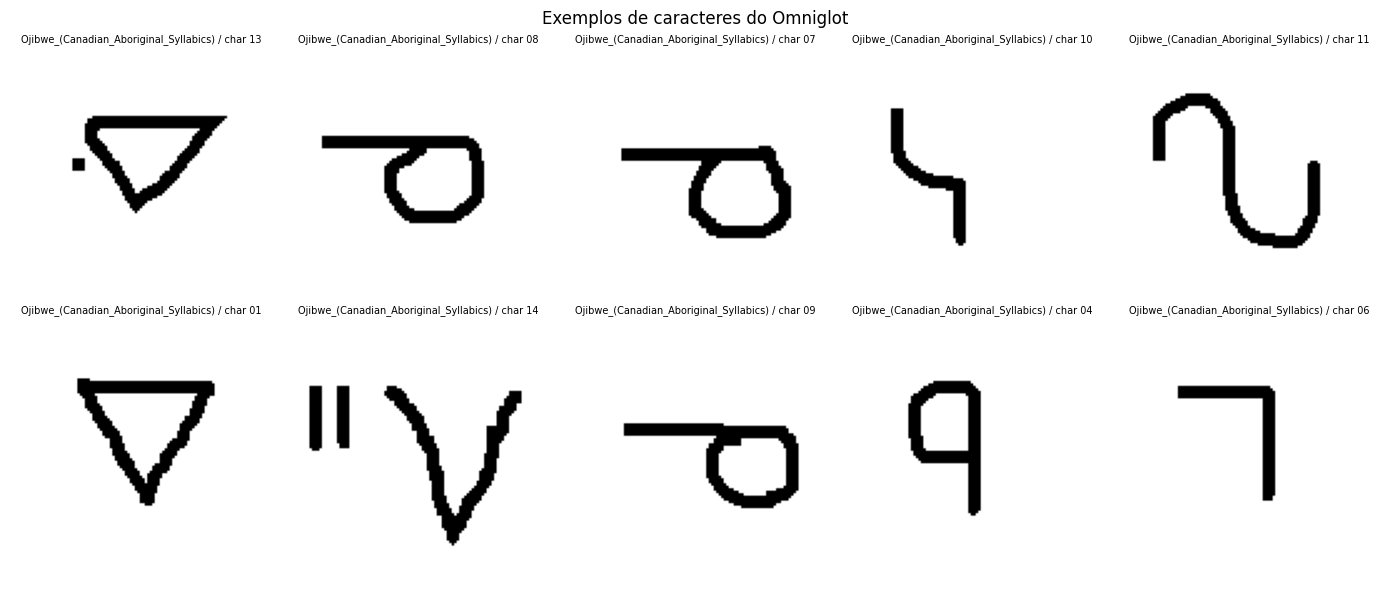

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, char_idx in zip(axes.ravel(), range(0, 200, 20)):  # +20 pula para o proximo caractere
    img, label = omniglot_background[char_idx]
    ax.imshow(img, cmap='gray')
    nome = omniglot_background._characters[label].replace('/character', ' / char ')
    ax.set_title(nome, fontsize=7)
    ax.axis('off')
plt.suptitle("Exemplos de caracteres do Omniglot")
plt.tight_layout()
plt.show()

### As 20 variações de um mesmo caractere

Cada uma das 20 imagens de um caractere foi traçada por uma pessoa diferente. Isso gera variação natural de espessura, inclinação e proporção, e mostra por que o modelo precisa aprender a essência do caractere em vez de memorizar pixels.

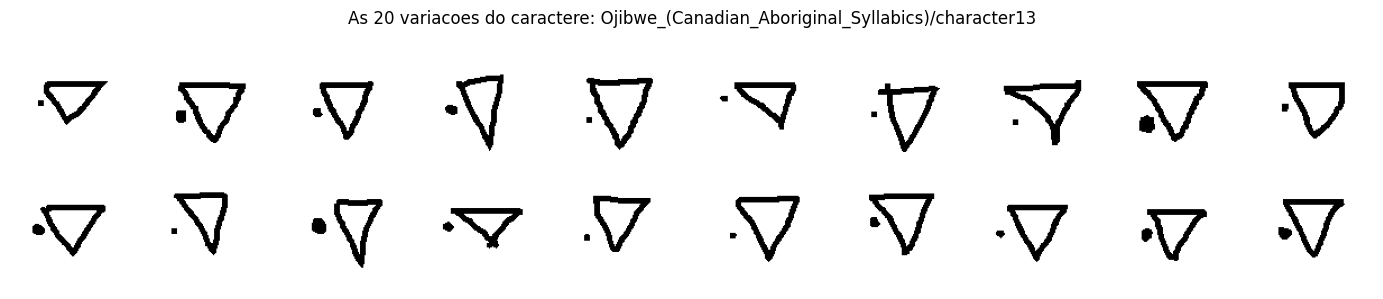

In [10]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.ravel()):
    img, label = omniglot_background[i]  # os 20 primeiros itens sao o mesmo caractere
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.suptitle(f"As 20 variacoes do caractere: {omniglot_background._characters[0]}")
plt.tight_layout()
plt.show()

### Gerando Pares Positivos com *Data Augmentation*

No aprendizado contrastivo auto-supervisionado, no estilo **SimCLR**, um par positivo é formado por duas visões aumentadas da mesma imagem. Aplicamos transformações aleatórias que preservam a identidade do caractere mas alteram sua aparência: rotações, translações, mudanças de escala e recortes. O modelo aprende a ignorar essas variações e focar no conteúdo.

Definimos uma pipeline de aumentação e a aplicamos duas vezes de forma independente sobre cada imagem.

In [11]:
IMG_SIZE = 28

# Pipeline de aumentacao: gera visoes diferentes preservando a identidade do caractere
augment = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.ToTensor(),  # converte para [0, 1], shape [1, 28, 28]
])

# Transformacao deterministica (sem aumentacao) usada na inferencia/avaliacao
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [13]:
class ContrastiveOmniglotDataset(Dataset):
    """Para cada imagem, retorna DUAS visoes aumentadas (par positivo) e o rotulo.

    O rotulo NAO e usado no treino contrastivo (que e auto-supervisionado);
    ele e mantido apenas para fins de inspecao e visualizacao.
    """
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]            # img: PIL Image
        view1 = self.transform(img)            # primeira visao aumentada
        view2 = self.transform(img)            # segunda visao aumentada (independente)
        return view1, view2, label

contrastive_dataset = ContrastiveOmniglotDataset(omniglot_background, augment)
print(f"Tamanho do dataset contrastivo: {len(contrastive_dataset)}")

Tamanho do dataset contrastivo: 19280


Vamos visualizar alguns pares positivos. Cada coluna mostra duas visões aumentadas da mesma imagem, diferentes entre si mas claramente o mesmo caractere.

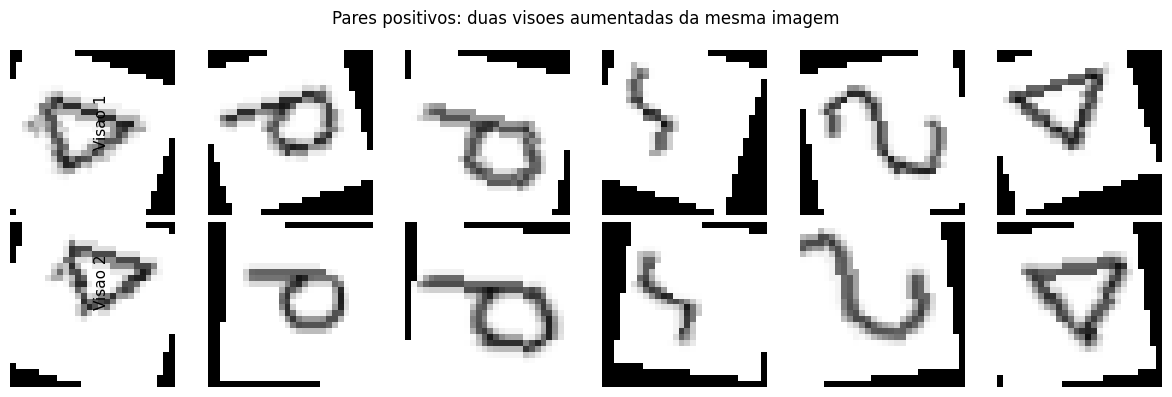

In [14]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for col in range(6):
    v1, v2, label = contrastive_dataset[col * 20]
    axes[0, col].imshow(v1.squeeze(), cmap='gray')
    axes[1, col].imshow(v2.squeeze(), cmap='gray')
    axes[0, col].axis('off')
    axes[1, col].axis('off')
fig.text(0.09, 0.70, "Visao 1", va='center', rotation='vertical', fontsize=11)
fig.text(0.09, 0.30, "Visao 2", va='center', rotation='vertical', fontsize=11)
plt.suptitle("Pares positivos: duas visoes aumentadas da mesma imagem")
plt.tight_layout()
plt.show()

### DataLoader

Agrupamos as visões em *batches*. O tamanho do *batch* é importante no aprendizado contrastivo: quanto maior, mais negativos ficam disponíveis para a perda InfoNCE em cada passo, o que costuma melhorar as representações.

In [15]:
BATCH_SIZE = 256

train_loader = DataLoader(
    contrastive_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    drop_last=True,   # descartamos o ultimo batch incompleto para manter shapes consistentes
)

# Inspecao de um batch
v1, v2, labels = next(iter(train_loader))
print(f"Shape de uma visao (batch): {v1.shape}")  # [B, 1, 28, 28]
print(f"Total de visoes por batch (2N): {2 * v1.shape[0]}")

Shape de uma visao (batch): torch.Size([256, 1, 28, 28])
Total de visoes por batch (2N): 512


## Arquitetura do Modelo

Seguindo o **SimCLR**, o modelo tem duas partes:

1. **Encoder** $f(\cdot)$: uma CNN que extrai uma representação $h$ da imagem. É a parte que queremos aprender; após o treino, $h$ é usado nas tarefas seguintes, como classificação e busca.
2. **Cabeça de Projeção** $g(\cdot)$: um MLP que mapeia $h$ em um vetor $z$ de menor dimensão, onde a perda contrastiva é calculada. Descartamos $g$ após o treino, pois calcular a perda no espaço projetado costuma gerar um $h$ de melhor qualidade.

### Encoder

Usamos uma CNN compacta com três blocos convolucionais de Conv, BatchNorm, ReLU e MaxPool. Ao final, um *pooling* adaptativo e uma camada linear produzem a representação $h$ de dimensão `embed_dim`.

In [16]:
class Encoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            # Bloco 1: [1, 28, 28] -> [32, 14, 14]
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Bloco 2: [32, 14, 14] -> [64, 7, 7]
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Bloco 3: [64, 7, 7] -> [128, 3, 3]
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Pooling adaptativo -> [128, 1, 1]
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, x):
        x = self.features(x)          # [B, 128, 1, 1]
        x = torch.flatten(x, 1)       # [B, 128]
        h = self.fc(x)                # [B, embed_dim]  -> representacao h
        return h

### Cabeça de Projeção e Modelo Completo

A cabeça de projeção é um MLP com uma camada oculta e ativação ReLU. O `ContrastiveModel` encadeia o encoder e a projeção: o método `forward` retorna $z$ para a perda, e `encode` retorna apenas $h$ para a inferência.

In [17]:
class ProjectionHead(nn.Module):
    def __init__(self, embed_dim=128, hidden_dim=128, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, h):
        return self.net(h)


class ContrastiveModel(nn.Module):
    def __init__(self, embed_dim=128, proj_dim=64):
        super().__init__()
        self.encoder = Encoder(embed_dim)
        self.projection = ProjectionHead(embed_dim, embed_dim, proj_dim)

    def forward(self, x):
        h = self.encoder(x)           # representacao (usada na inferencia)
        z = self.projection(h)        # projecao (usada na perda contrastiva)
        return z

    def encode(self, x):
        """Retorna apenas a representacao h, sem a cabeca de projecao."""
        return self.encoder(x)

## Função de Perda: InfoNCE

Vamos implementar a versão usada no SimCLR, chamada **NT-Xent**. O procedimento é:

1. Receber as projeções das duas visões, $z_1$ e $z_2$, cada uma com $N$ vetores.
2. Concatená-las em uma matriz $z$ de $2N$ vetores e normalizá-los para norma L2 igual a 1, de modo que o produto interno seja a similaridade do cosseno.
3. Calcular a matriz de similaridade $2N \times 2N$ e dividi-la pela temperatura $\tau$.
4. Mascarar a diagonal com $-\infty$, pois um vetor não é positivo de si mesmo.
5. Definir o alvo de cada linha $i$: a visão $i$ tem como positivo a visão $i + N$, e vice-versa.
6. Aplicar uma entropia cruzada sobre as linhas, atribuindo a maior similaridade ao positivo correto.

In [18]:
def info_nce_loss(z1, z2, temperature=0.5):
    """Calcula a perda InfoNCE (NT-Xent) para dois conjuntos de projecoes.

    z1, z2: tensores [N, D] com as projecoes das duas visoes.
    """
    N = z1.size(0)

    # 1-2) Concatena e normaliza (norma L2 = 1)
    z = torch.cat([z1, z2], dim=0)          # [2N, D]
    z = F.normalize(z, dim=1)

    # 3) Matriz de similaridade do cosseno, escalada pela temperatura
    sim = torch.matmul(z, z.T) / temperature  # [2N, 2N]

    # 4) Mascara a diagonal (auto-similaridade) com -infinito
    self_mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(self_mask, float('-inf'))

    # 5) Alvos: o positivo da visao i (i < N) esta na posicao i + N, e vice-versa
    targets = torch.cat([
        torch.arange(N, 2 * N),
        torch.arange(0, N),
    ]).to(z.device)

    # 6) Entropia cruzada sobre as 2N linhas
    loss = F.cross_entropy(sim, targets)
    return loss

Antes de treinar, fazemos um teste de sanidade. Com vetores idênticos nas duas visões a perda deve ser baixa; com vetores aleatórios deve ser maior.

In [19]:
with torch.no_grad():
    base = F.normalize(torch.randn(8, 64), dim=1)
    # Caso ideal: as duas visoes sao identicas
    loss_ideal = info_nce_loss(base, base.clone(), temperature=0.5)
    # Caso aleatorio: visoes sem nenhuma relacao
    loss_random = info_nce_loss(torch.randn(8, 64), torch.randn(8, 64), temperature=0.5)

print(f"Perda com pares identicos (ideal): {loss_ideal.item():.4f}")
print(f"Perda com pares aleatorios:       {loss_random.item():.4f}")

Perda com pares identicos (ideal): 1.0608
Perda com pares aleatorios:       2.7013


## Treinamento

Instanciamos o modelo e o otimizador **Adam**. Não há rótulos: a única supervisão são os pares positivos gerados pela aumentação. Treinaremos por algumas épocas acompanhando a queda da perda InfoNCE.

In [20]:
embed_dim = 128
proj_dim = 64
temperature = 0.5
learning_rate = 1e-3
num_epochs = 15

model = ContrastiveModel(embed_dim=embed_dim, proj_dim=proj_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parametros treinaveis: {n_params:,}")

Parametros treinaveis: 134,400


In [21]:
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for view1, view2, _ in train_loader:
        view1 = view1.to(device)
        view2 = view2.to(device)

        # Forward: projeta cada visao
        z1 = model(view1)
        z2 = model(view2)

        # Perda contrastiva InfoNCE
        loss = info_nce_loss(z1, z2, temperature=temperature)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoca: {epoch+1:02d}/{num_epochs:02d} | Perda InfoNCE: {avg_loss:.4f}")

Epoca: 01/15 | Perda InfoNCE: 5.1497
Epoca: 02/15 | Perda InfoNCE: 4.8316
Epoca: 03/15 | Perda InfoNCE: 4.7468
Epoca: 04/15 | Perda InfoNCE: 4.7126
Epoca: 05/15 | Perda InfoNCE: 4.6869
Epoca: 06/15 | Perda InfoNCE: 4.6752
Epoca: 07/15 | Perda InfoNCE: 4.6543
Epoca: 08/15 | Perda InfoNCE: 4.6385
Epoca: 09/15 | Perda InfoNCE: 4.6312
Epoca: 10/15 | Perda InfoNCE: 4.6205
Epoca: 11/15 | Perda InfoNCE: 4.6076
Epoca: 12/15 | Perda InfoNCE: 4.6050
Epoca: 13/15 | Perda InfoNCE: 4.5970
Epoca: 14/15 | Perda InfoNCE: 4.5907
Epoca: 15/15 | Perda InfoNCE: 4.5773


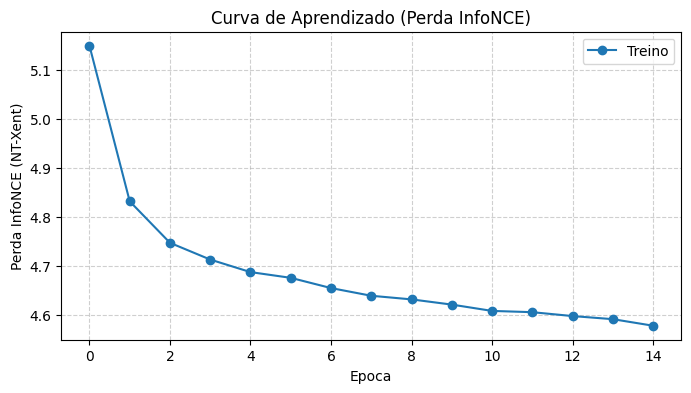

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Treino", color="#1f77b4", marker="o")
plt.title("Curva de Aprendizado (Perda InfoNCE)")
plt.xlabel("Epoca")
plt.ylabel("Perda InfoNCE (NT-Xent)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Inferência

Após o treino, descartamos a cabeça de projeção e usamos apenas o `encoder` para extrair representações $h$. Queremos saber se essas representações, aprendidas sem rótulos no conjunto *background*, são úteis para alfabetos inéditos.

Faremos duas avaliações: uma classificação *few-shot* no conjunto de avaliação e uma visualização do espaço de *embeddings*.

In [23]:
@torch.no_grad()
def extract_embeddings(encoder, images):
    """Recebe um tensor [N, 1, 28, 28] e retorna embeddings normalizados [N, embed_dim]."""
    encoder.eval()
    images = images.to(device)
    h = encoder(images)
    h = F.normalize(h, dim=1)   # normalizamos para usar distancia/similaridade do cosseno
    return h.cpu()

### Classificação *Few-Shot* em classes inéditas

Montamos um episódio de avaliação no conjunto `background=False`, com alfabetos nunca vistos no treino:

- Escolhemos $N$ caracteres aleatórios, o chamado N-way.
- Para cada um, separamos $K$ imagens de suporte com rótulo conhecido e algumas imagens de consulta.
- Classificamos cada consulta pelo centroide de suporte mais próximo no espaço de *embeddings*.

Um *encoder* não treinado teria desempenho próximo do acaso, igual a $1/N$. Esperamos que o encoder treinado supere esse valor, indicando que as representações generalizam.

In [24]:
# Conjunto de avaliacao: caracteres de alfabetos NUNCA vistos no treino
omniglot_eval = Omniglot(root='data', background=False, download=True, transform=basic_transform)

# Agrupa os indices das imagens por classe
from collections import defaultdict
class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(omniglot_eval._flat_character_images):
    class_to_indices[label].append(idx)

num_eval_classes = len(class_to_indices)
print(f"Classes no conjunto de avaliacao: {num_eval_classes}")

100%|██████████| 6.46M/6.46M [00:00<00:00, 76.4MB/s]


Classes no conjunto de avaliacao: 659


In [25]:
def run_few_shot_episode(encoder, n_way=5, k_shot=5, n_query=5, rng=None):
    rng = rng or random.Random()
    chosen_classes = rng.sample(list(class_to_indices.keys()), n_way)

    support_imgs, support_labels = [], []
    query_imgs, query_labels = [], []
    for new_label, cls in enumerate(chosen_classes):
        idxs = rng.sample(class_to_indices[cls], k_shot + n_query)
        for i in idxs[:k_shot]:
            support_imgs.append(omniglot_eval[i][0])
            support_labels.append(new_label)
        for i in idxs[k_shot:]:
            query_imgs.append(omniglot_eval[i][0])
            query_labels.append(new_label)

    support_imgs = torch.stack(support_imgs)
    query_imgs = torch.stack(query_imgs)
    support_labels = torch.tensor(support_labels)
    query_labels = torch.tensor(query_labels)

    # Embeddings
    support_emb = extract_embeddings(encoder, support_imgs)
    query_emb = extract_embeddings(encoder, query_imgs)

    # Centroide (prototipo) de cada classe de suporte
    prototypes = torch.stack([
        support_emb[support_labels == c].mean(dim=0) for c in range(n_way)
    ])
    prototypes = F.normalize(prototypes, dim=1)

    # Classifica cada consulta pelo prototipo mais similar (similaridade do cosseno)
    sims = query_emb @ prototypes.T          # [num_query, n_way]
    preds = sims.argmax(dim=1)
    accuracy = (preds == query_labels).float().mean().item()
    return accuracy

# Media da acuracia em varios episodios
rng = random.Random(0)
N_WAY, K_SHOT = 5, 5
accs = [run_few_shot_episode(model.encoder, n_way=N_WAY, k_shot=K_SHOT, n_query=5, rng=rng)
        for _ in range(200)]
print(f"Acuracia {N_WAY}-way {K_SHOT}-shot (media de 200 episodios): {np.mean(accs)*100:.1f}% "
      f"(acaso = {100/N_WAY:.1f}%)")

Acuracia 5-way 5-shot (media de 200 episodios): 92.6% (acaso = 20.0%)


### Visualizando o espaço de *embeddings*

Projetamos os *embeddings* de algumas classes inéditas em 2D com **t-SNE**. Se o treino funcionou, imagens do mesmo caractere devem formar agrupamentos bem separados, mesmo sem terem sido vistas no treino.

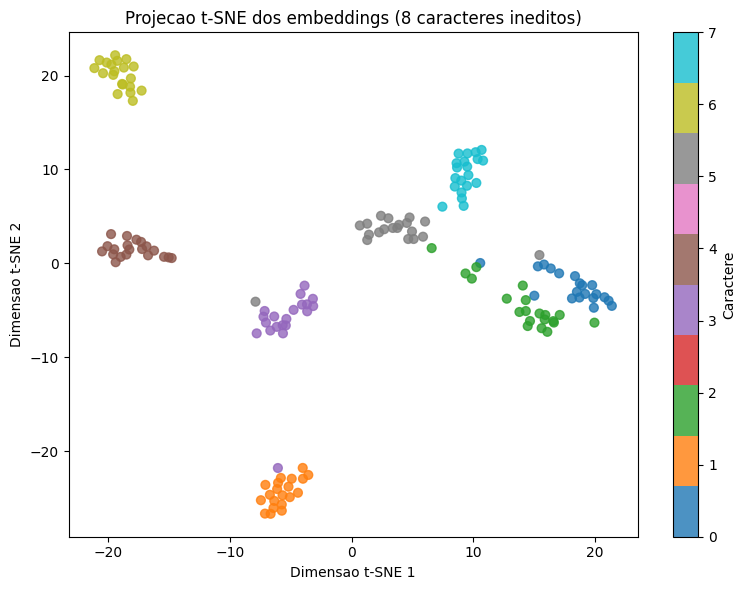

In [26]:
from sklearn.manifold import TSNE

# Seleciona 8 classes de avaliacao e ate 20 imagens de cada
rng = random.Random(7)
selected = rng.sample(list(class_to_indices.keys()), 8)

imgs, labels = [], []
for new_label, cls in enumerate(selected):
    for i in class_to_indices[cls][:20]:
        imgs.append(omniglot_eval[i][0])
        labels.append(new_label)
imgs = torch.stack(imgs)
labels = np.array(labels)

emb = extract_embeddings(model.encoder, imgs).numpy()
emb_2d = TSNE(n_components=2, perplexity=15, init='pca', random_state=42).fit_transform(emb)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab10', s=40, alpha=0.8)
plt.title("Projecao t-SNE dos embeddings (8 caracteres ineditos)")
plt.xlabel("Dimensao t-SNE 1")
plt.ylabel("Dimensao t-SNE 2")
plt.colorbar(scatter, label="Caractere", ticks=range(8))
plt.tight_layout()
plt.show()

### Busca por similaridade

Outra aplicação das representações é a busca por similaridade: dada uma imagem de consulta, recuperamos as mais parecidas pela similaridade do cosseno entre os *embeddings*. Boas representações recuperam imagens do mesmo caractere.

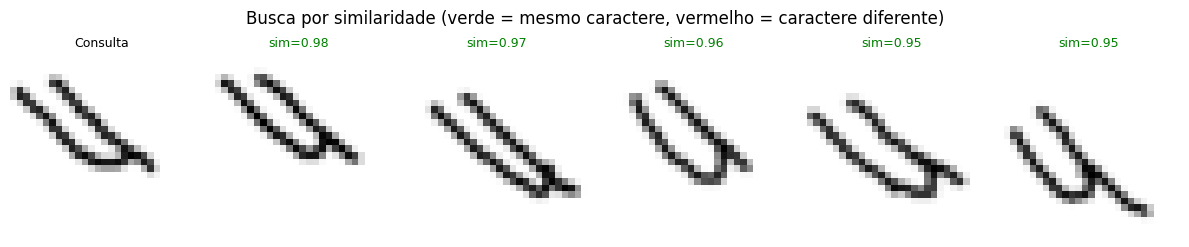

In [29]:
# Banco de imagens (galeria): 12 imagens de cada uma de 10 classes ineditas
rng = random.Random(5)
gallery_classes = rng.sample(list(class_to_indices.keys()), 10)
gallery_imgs, gallery_labels = [], []
for cls in gallery_classes:
    for i in class_to_indices[cls][:12]:
        gallery_imgs.append(omniglot_eval[i][0])
        gallery_labels.append(cls)
gallery_imgs = torch.stack(gallery_imgs)
gallery_labels = torch.tensor(gallery_labels)
gallery_emb = extract_embeddings(model.encoder, gallery_imgs)

# Escolhemos uma imagem de consulta e buscamos as mais parecidas na galeria,
# EXCLUINDO a propria consulta dos resultados.
query_idx = 0
sims = (gallery_emb[query_idx:query_idx + 1] @ gallery_emb.T).squeeze(0)
sims[query_idx] = float('-inf')               # remove a propria consulta do ranking
top5 = sims.argsort(descending=True)[:5]

fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
# Primeiro painel: a imagem de consulta
axes[0].imshow(gallery_imgs[query_idx].squeeze(), cmap='gray')
axes[0].set_title("Consulta", fontsize=9)
axes[0].axis('off')
# Demais paineis: os 5 vizinhos mais proximos
for ax, idx in zip(axes[1:], top5.tolist()):
    ax.imshow(gallery_imgs[idx].squeeze(), cmap='gray')
    acerto = gallery_labels[idx] == gallery_labels[query_idx]
    ax.set_title(f"sim={sims[idx]:.2f}", fontsize=9, color=('green' if acerto else 'red'))
    ax.axis('off')
plt.suptitle("Busca por similaridade (verde = mesmo caractere, vermelho = caractere diferente)")
plt.tight_layout()
plt.show()

## Exercícios

### Exercício 1: O papel da temperatura $\tau$
Treine novamente o modelo com `temperature=0.1` e `temperature=1.0` e reavalie a acurácia *few-shot* em cada caso. Como a temperatura afeta a separação dos agrupamentos e o desempenho final?

### Exercício 2: Impacto do tamanho do *batch*
Reduza o `BATCH_SIZE` para 32 e depois aumente para 512, mantendo o resto fixo. Compare as curvas de perda e a acurácia *few-shot*. Lembre-se de que o número de negativos por passo é $2N - 2$. O que você observa?

### Exercício 3: A importância da aumentação
As transformações em `augment` definem o que o modelo considera irrelevante. Experimente remover a `RandomAffine` e também adicionar uma aumentação agressiva como `degrees=90`. Como isso afeta a qualidade das representações? Há transformações que destroem a identidade do caractere?